# Homework 1: SOLUTIONS 

### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Problem 1
* Generate a sample of 10,000 data values drawn from N($\mu$=1.0, $\sigma$=0.2)and draw a pretty histogram
with the bin size determined using the Freedman-Diaconis rule. Show (Poissonian) uncertainty ($N_{bin} \pm \sqrt{N_{bin}}$, where $N_{bin}$ is the count in a given bin) for each histogram value, and overplot the true distribution.


## Problem 2
* Do the same for a Cauchy distribution with the same $\mu$ and $\gamma$=0.2.

## Problem 3
* Compute mean and its uncertainty for both samples and comment on their differences. 

## Problem 4:
Four different studies measured the abundance of planetary systems around main sequence stars of different spectral types (&lt;F, G, K, &gt;M). What is the probability a randomly chosen (== typical) main sequence star will harbor a planetary system? Hint: use the law of total probabilities. 

|Spectral type|Fraction with systems|Fraction of MS stars with this spectral type|
| --- | ---- | ---  |
| < F | 0.1  | 0.1  |
|   G | 0.3  | 0.15 |
|   K | 0.45 | 0.25 |
| > M | 0.7  | 0.5  |

(note: the numbers in this table above are for illustration only, and do not correspond to actual observed rates).

## Problem 5:
* Generate a sample of 100 data values drawn from N($\mu$=1.0, $\sigma$=0.1). Draw 3 values from N($\mu$=10.0, $\sigma$=1.0) and add them to the first sample. Compute the mean and median values for this extended sample 
and discuss how similar they are. 

## Problem 6:
* You are playing a game show and are shown 2 doors.  One has a car behind it, the other a goat.  What are your chances of picking the door with the car (assumed to be much more valuable than goat)?

## Problem 7:
* Now there are 3 doors: one with a car, two with goats. The game show host asks you to pick a door, but not to open it yet. Then the host opens one of the other two doors (that you did not pick), making sure to select one with a goat. The host offers you the opportunity to switch doors. Do you switch? Hint: use conditional probabilities.

## Problem 8:
* Generate a sample of N=10 data values drawn from $N$($\mu$=1.0, $\sigma$=0.1). Plot the likelihood function for $\mu$ given these 10 values. Overplot the prediction that says it should look like $N$($\overline{x}, \sigma_\overline{x}$),
where
$$\overline{x} \equiv \frac{1}{N}\sum_{i=1}^N x_i,$$
and
$$ \sigma_\overline{x} = \frac{s}{\sqrt N},$$ and comment. 

## Problem 9:
* An astronomer looked at 10 galaxies and found that 3 harbor black holes. What is the probability that no more than 50\% of galaxies harbor black holes? How would that conclusion change if astronomer repeated that study with
100 galaxies and found that 30 harbor black holes? And 1000 galaxies, of which 300 harbor black holes. 

Hint: use the binomial likelihood example from Week2 lecture. 

## Problem 10: 

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* Define probability distribution function (pdf) and describe the difference between population pdf and empirical pdf. 

* State the law of total probability. 

* What is a marginal distribution? 

* When is better to use the median than the mean as an estimator of location parameter? 

* Explain the difference between accuracy and precision

* State the Central Limit Theorem and discuss its importance. 

* State uncertainty of the location parameter when estimated using the  mean value (hint: recall the Central Limit Theorem)

* What is a histogram? 

* How would you estimate the location parameter for a Gaussian distribution using  the Maximum Likelihood Method?  Would it matter whether its scale parameter ($\sigma$) is known? 

* How would you measure the goodness of fit? 

# Solutions

### Some useful definitions and functions

In [48]:
import numpy as np
from matplotlib import pyplot as plt

## Problem 1

Text(0, 0.5, 'counts')

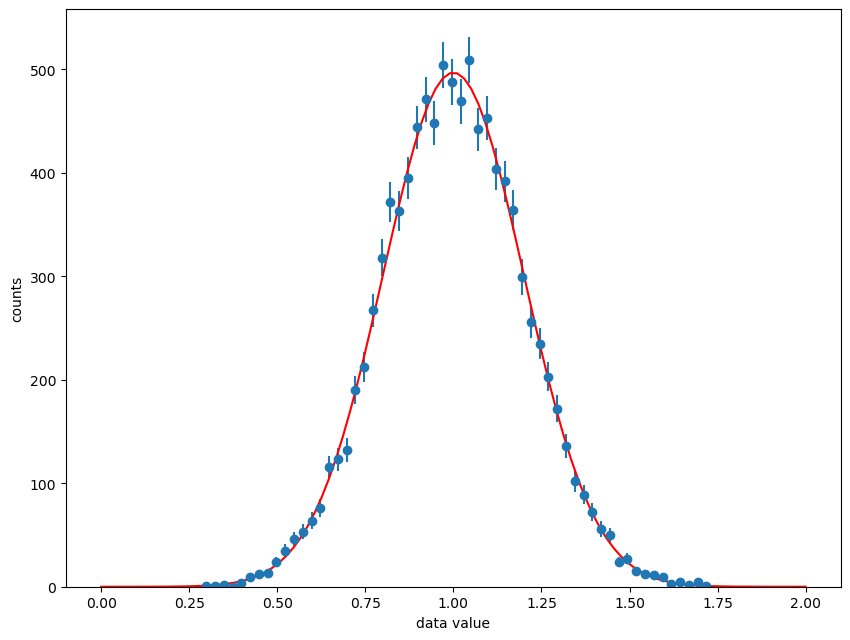

In [10]:
from scipy.stats import norm
np.random.seed(83)

# "data"
M= 10000
mu = 1.0
sigma = 0.2
values = norm(mu, sigma).rvs(M) 

fig, ax = plt.subplots(figsize = (10, 7.5))

# use ax.hist because it knows about the Freedman-Diaconis rule but don't plot histogram
N, binEdges, p = ax.hist(values, bins='fd', color='w')
# obtain bin width and bin center array 
binWidth = binEdges[1]-binEdges[0]
bins = binEdges[:-1]+0.5*binWidth
# and plot as symbols with error bars
plt.errorbar(bins, N, yerr=np.sqrt(N), fmt='o') 

# now plot true distribution
x = np.linspace(mu-5*sigma, mu+5*sigma, 100)
gauss = M*binWidth*norm(mu, sigma).pdf(x)  # this is a function of x: gauss(x)
plt.plot(x, gauss, ls='-', c='red')

ax.set_xlabel("data value")
ax.set_ylabel("counts")

## Problem 2

In [14]:
from scipy.stats import cauchy
np.random.seed(42)

# "data"
M= 10000
mu = 1.0
gamma = 0.2
valuesC = cauchy(mu, gamma).rvs(M) 

Text(0, 0.5, 'counts')

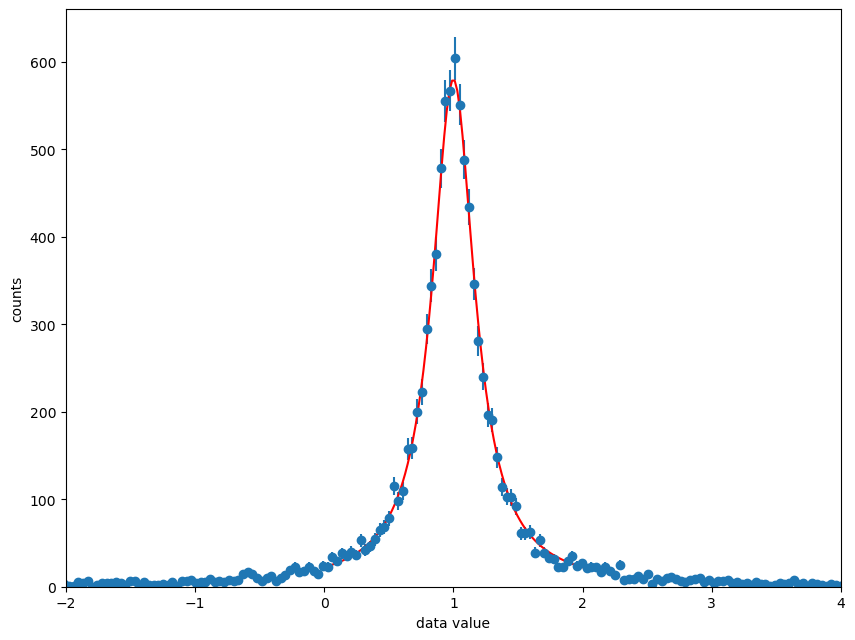

In [15]:
fig, ax = plt.subplots(figsize = (10, 7.5))

# use ax.hist because it knows about the Freedman-Diaconis rule but don't plot histogram
N, binEdges, p = ax.hist(valuesC, bins='fd', color='w')
# obtain bin width and bin center array 
binWidth = binEdges[1]-binEdges[0]
bins = binEdges[:-1]+0.5*binWidth
# and plot as symbols with error bars
plt.errorbar(bins, N, yerr=np.sqrt(N), fmt='o') 

# now plot true distribution
x = np.linspace(mu-5*sigma, mu+5*sigma, 100)
cauchyFunc = M*binWidth*cauchy(mu, gamma).pdf(x)  
plt.plot(x, cauchyFunc, ls='-', c='red')
plt.xlim(-2, 4)

ax.set_xlabel("data value")
ax.set_ylabel("counts")

## Problem 3

In [16]:
# Gaussian
muG = np.mean(values)
sigG = np.std(values) / np.sqrt(M)
# Cauchy
muC = np.mean(valuesC)
sigC = np.std(valuesC) / np.sqrt(M)
print(f"Gaussian: {muG:.4f} ± {sigG:.4f}")
print(f"Cauchy: {muC:.4f} ± {sigC:.4f}")

Gaussian: 0.9998 ± 0.0020
Cauchy: -0.0112 ± 0.6039


The uncertainty of the mean for the Cauchy distribution is much larger than for the Gaussian distribution.
This reflects much larger standard deviation, which is due to heavy tails of the Cauchy distribution. 

## Problem 4

In [18]:
pPS = [0.1, 0.3, 0.45, 0.7]
pSpT= [0.1, 0.15, 0.25, 0.5]
pTot = 0
for i in range(len(pPS)):
    pTot += pPS[i] * pSpT[i]

print(pTot)

0.5175


## Problem 5

In [22]:
np.random.seed(42)

# core
muC = 1
sigC = 0.1
nC = 100
#tails
muT = 10
sigT = 1
nT = 3

data = list(norm(muC, sigC).rvs(nC)) + list(norm(muT, sigT).rvs(nT))
print('mean:', np.mean(data), '  median:', np.median(data))

print('The mean is much further from true location at 1.0 than the median because it is sensitive to outliers.')

mean: 1.2309010120846264   median: 0.9927989878419666
The mean is much further from true location at 1.0 than the median because it is sensitive to outliers.


## Problem 6

The probability of picking the door with the car is 0.5.

## Problem 7

The probability that the car is behind the door that you picked is 1/3. Therefore, the probability that the 
car is behind the other unopened door must be 2/3 and it pays to switch. 

## Problem 8

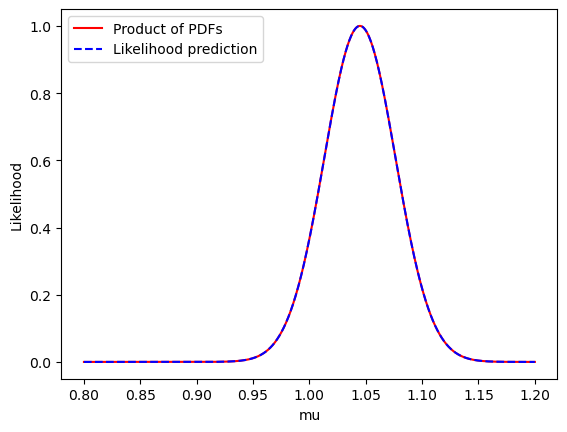

In [37]:
np.random.seed(42)
# data
mu = 1.0
sigma = 0.1
N = 10
x = norm(mu, sigma).rvs(N)

# now plot
muGrid = np.linspace(0.8, 1.2, 1000)
Lvalues = []
for mu_i in muGrid:
    L_i = np.prod(norm(mu_i, sigma).pdf(x))
    Lvalues.append(L_i)
Lvalues = np.array(Lvalues)
Lvalues = Lvalues / np.max(Lvalues)
plt.plot(muGrid, Lvalues, color='red', label='Product of PDFs')

xbar = np.mean(x)
sigma_xbar = sigma / np.sqrt(N)
L_xbar = (norm(xbar, sigma_xbar).pdf(muGrid))
L_xbar = L_xbar / np.max(L_xbar)
plt.plot(muGrid, L_xbar, '--b', label='Likelihood prediction')
plt.xlabel("mu")
plt.ylabel("Likelihood")
plt.legend()
plt.show()

## Problem 9

In [43]:
from scipy.special import comb
from scipy.integrate import trapezoid 

def plotP9(N, k, plot=False):

    p_grid = np.linspace(0, 1, 1000)

    L = comb(N, k) * p_grid**k * (1 - p_grid)**(N-k)
    if plot:
        plt.plot(p_grid, L, color='red')
        plt.xlabel("p")
        plt.ylabel("Likelihood")
 
    mask = p_grid <= 0.5
    prob = np.trapezoid(L[mask], p_grid[mask]) / np.trapezoid(L, p_grid)

    print('p=', prob)

p= 0.8860714189003869
p= 0.99997112338208
p= 1.0


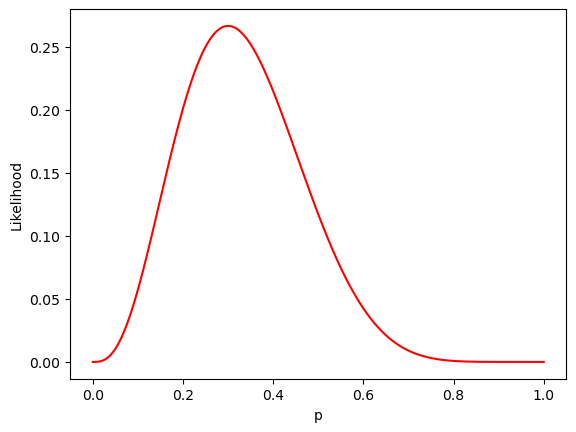

In [46]:
plotP9(10, 3, plot=True)
plotP9(100, 30)
plotP9(1000, 300)

p= 1.0


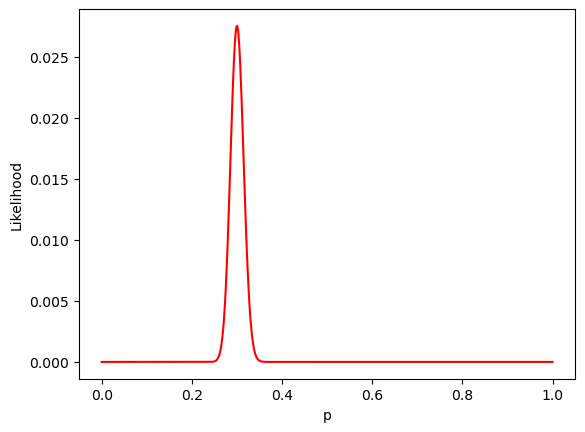

In [47]:
plotP9(1000, 300, plot=True)

## Problem 10

* Define probability distribution function (pdf) and describe the difference between population pdf and empirical pdf. 

A pdf describes the probability distribution of a continuous random variable. A population pdf is the true underlying distribution from which data were drawn. Empirical pdf is an estimate constructed from observed data (e.g. a histogram).

* State the law of total probability. 

$$ P(B) = \sum_i P(B|A_i)P(A_i) $$

* What is a marginal distribution? 

A marginal distribution is a multi-dimensional distribution projected to a subspace of all dimensions. 
For example, a 2D distribution can be integrated over one variable to obtain a marginal distribution for
the other variable. 
 
* When is better to use the median than the mean as an estimator of location parameter? 

The median is a more robust estimator than the mean (i.e. much sensitive to outliers). 

* Explain the difference between accuracy and precision

Accuracy reflects closeness to the true value, while precision represents consistency between repeated measurements.

* State the Central Limit Theorem and discuss its importance. 

The sample mean asymptotically approaches a Gaussian distribution centered on true location parameter as the sample size increases, with the scatter around the true value independent of the underlying distribution as long as
that distribution has a finite standard deviation. The Central Limit Theorem is important because of 
the generality of this result. 
 

* State uncertainty of the location parameter when estimated using the  mean value (hint: recall the Central Limit Theorem)

   $$ \sigma_\overline{x} = \frac{s}{\sqrt N}$$

* What is a histogram? 

A histogram a way to represent the distribution of sampled data by sorting the sample into bins (of either constant or variable width). A histogram can also be viewed as an attempt at approximating the underlying sample distribution with a piecewise constant function.

Histograms are a tool for early data visualization: they give us an idea of how the data are distributed and whether notable features exist in their distribution.

* How would you estimate the location parameter for a Gaussian distribution using the Maximum Likelihood Method?  Would it matter whether its scale parameter ($\sigma$) is known? 

By taking the first derivative of the likelihood with respect to the location parameter, and setting it to zero, 
it can be shown that the location parameter can be estimated as
    $$\overline{x} \equiv \frac{1}{N}\sum_{i=1}^N x_i$$

Although the likelihood function is different between the two cases with known and unknown $\sigma$, this 
result for the location parameter is valid in both cases (note: but its uncertainty is different for small samples). 


* How would you measure the goodness of fit? 

In general, the goodness of fit is measured using Bayesian model probability. When the posterior probability 
distribution asymptotically approaches gaussianity, the goodness of fit is measured using $\chi^2$ statistic.